# Social Media Impact on Teen Mental Health Analysis

## Setup

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,roc_curve, auc, ConfusionMatrixDisplay)
from matplotlib.ticker import PercentFormatter
from scipy.stats import f_oneway
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 69

## Info

In [2]:
df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   object 
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   object 
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   object 
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), object(3)
memory usage: 122.0+ KB


In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1200.0,NaN,NaN,NaN,15.928333,2.021947,13.0,14.0,16.0,18.0,19.0
gender,1200,2,male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_social_media_hours,1200.0,NaN,NaN,NaN,4.536667,2.029599,1.0,2.8,4.5,6.3,8.0
platform_usage,1200,3,Instagram,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,1200.0,NaN,NaN,NaN,6.449417,1.442677,4.0,5.2,6.5,7.6,9.0
screen_time_before_sleep,1200.0,NaN,NaN,NaN,1.740333,0.71666,0.5,1.1,1.8,2.4,3.0
academic_performance,1200.0,NaN,NaN,NaN,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,NaN,NaN,NaN,1.0145,0.582185,0.0,0.5,1.0,1.5,2.0
social_interaction_level,1200,3,medium,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress_level,1200.0,NaN,NaN,NaN,5.445833,2.90329,1.0,3.0,5.0,8.0,10.0


## Quality + Cleaning

In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Missing values per column:
age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

Total missing: 0
Duplicate rows: 0


In [6]:
for col in ["gender", "platform_usage", "social_interaction_level"]:
    print(col, "values", df[col].unique().tolist())
print("No missing values and no duplicate rows")

gender values ['male', 'female']
platform_usage values ['Instagram', 'TikTok', 'Both']
social_interaction_level values ['low', 'high', 'medium']
No missing values and no duplicate rows


In [7]:
data = df.copy()
data["gender_enc"] = (data["gender"] == "male").astype(int) #gender -> binary (male = 1, female = 0)
data["social_interaction_enc"] = data["social_interaction_level"].map({"low": 0, "medium": 1, "high": 2}) #social_interaction_level -> ordinal (low = 0, medium = 1, high = 2)
feature_cols = ["age", "gender_enc", "daily_social_media_hours", "sleep_hours","screen_time_before_sleep", "academic_performance", "physical_activity","social_interaction_enc", "stress_level", "anxiety_level","addiction_level", "depression_label"]
target_col = "platform_usage" #platform_usage -> left as the three-class target
X = data[feature_cols]
y = data[target_col]
print("Features:", feature_cols)
print("Target classes:", y.unique().tolist())

Features: ['age', 'gender_enc', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'social_interaction_enc', 'stress_level', 'anxiety_level', 'addiction_level', 'depression_label']
Target classes: ['Instagram', 'TikTok', 'Both']


## Exploratory Data Analysis

platform_usage
Instagram    411
TikTok       398
Both         391
Name: count, dtype: int64

Proportions:
platform_usage
Instagram    0.342
TikTok       0.332
Both         0.326
Name: proportion, dtype: float64


(array([0, 1, 2]),
 [Text(0, 0, 'Instagram'), Text(1, 0, 'TikTok'), Text(2, 0, 'Both')])

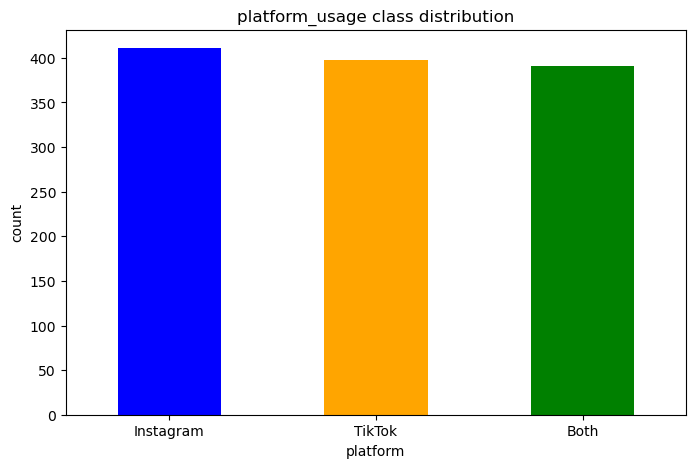

In [8]:
class_counts = y.value_counts()
print(class_counts)
print("\nProportions:")
print(y.value_counts(normalize=True).round(3))
ax = class_counts.plot(kind="bar", color=["blue", "orange", "green"])
ax.set_title("platform_usage class distribution")
ax.set_ylabel("count"); 
ax.set_xlabel("platform")
plt.xticks(rotation=0)

Three classes are nearly balanced. Interpretable against a ~33% chance baseline, class imbalance is not a concern

Text(0.5, 0.98, 'Distributions of continuous features')

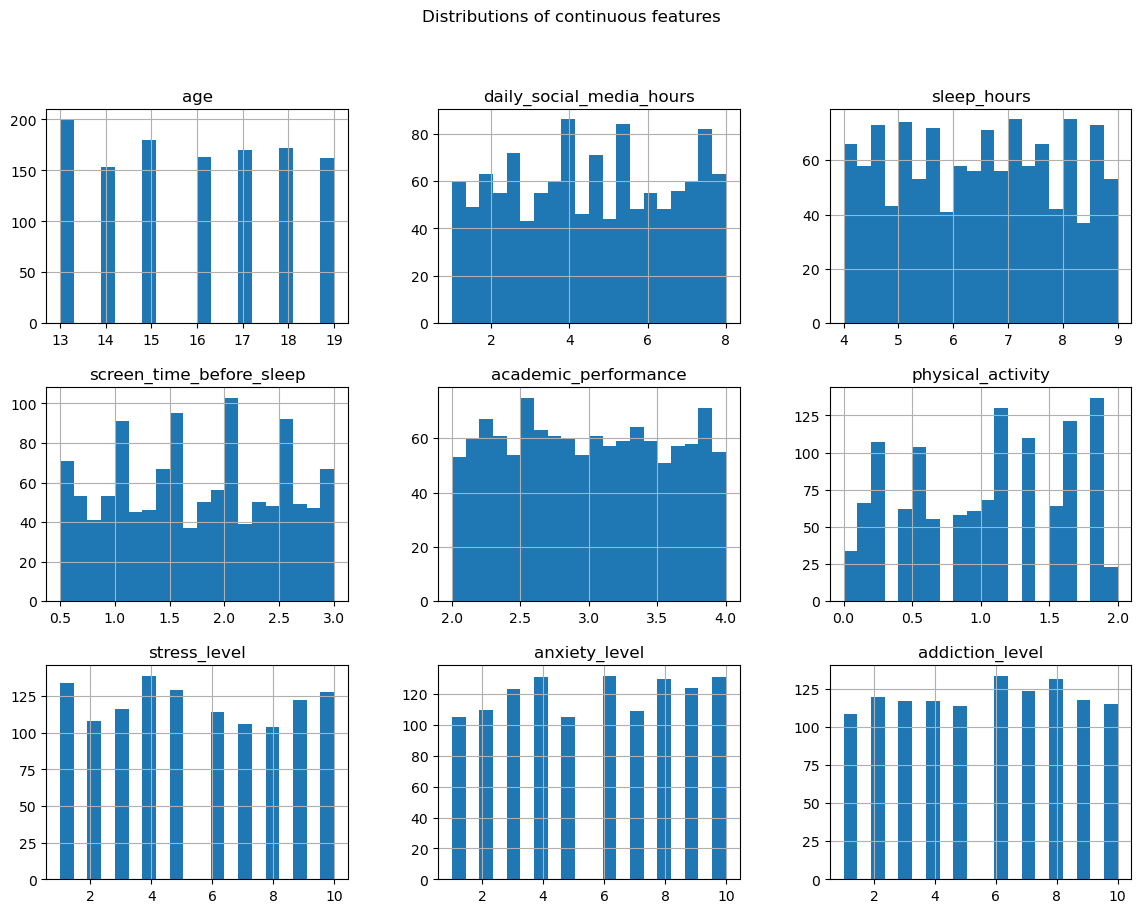

In [9]:
continuous = ["age", "daily_social_media_hours", "sleep_hours", "screen_time_before_sleep","academic_performance", "physical_activity", "stress_level","anxiety_level", "addiction_level"]
data[continuous].hist(bins=20, figsize=(14, 10))
plt.suptitle("Distributions of continuous features",)

Most variables are close to uniform across ranges rather than bell-shaped. Real surveys are normally skewed or peaked.

Text(0.5, 1.02, 'Feature distributions grouped by platform')

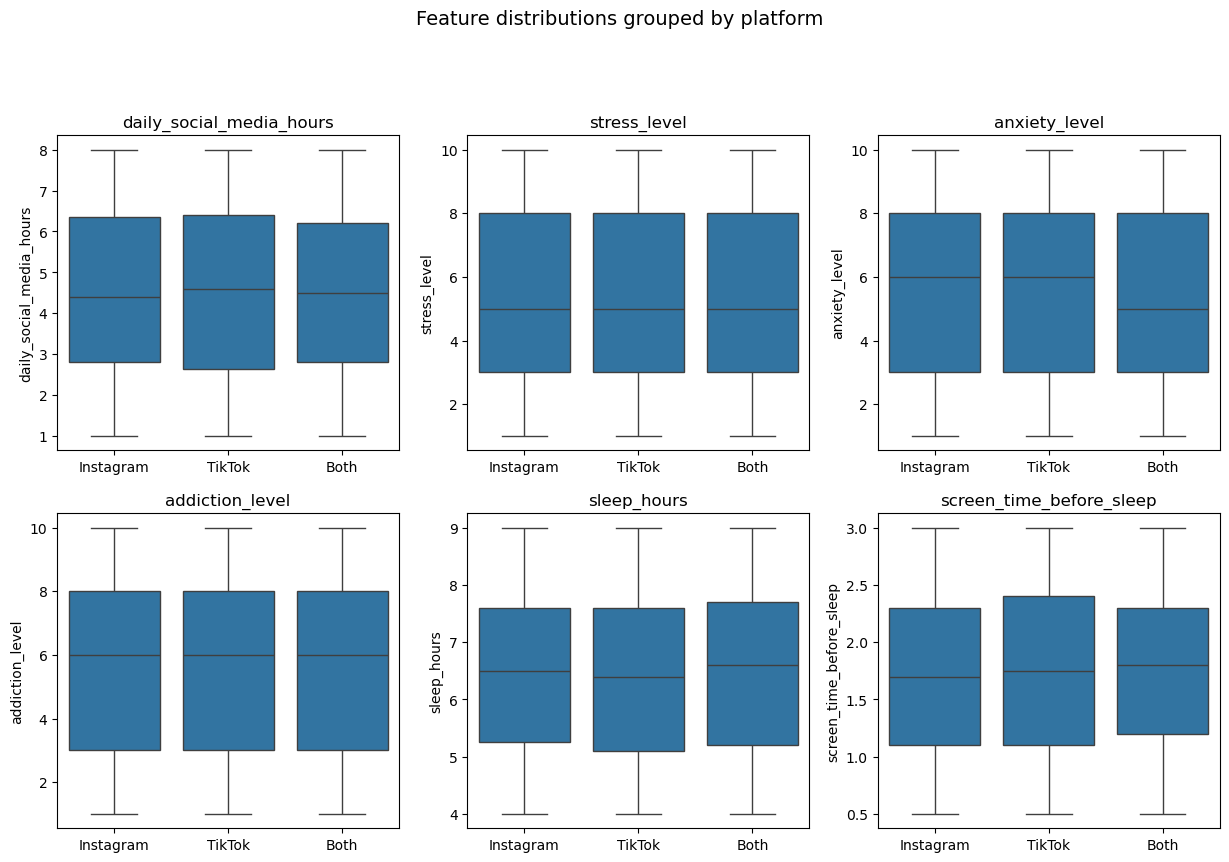

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
box_vars = ["daily_social_media_hours", "stress_level", "anxiety_level","addiction_level", "sleep_hours", "screen_time_before_sleep"]
for ax, var in zip(axes.ravel(), box_vars):
    sns.boxplot(data=data, x="platform_usage", y=var, ax=ax)
    ax.set_title(var)
    ax.set_xlabel("")
plt.suptitle("Feature distributions grouped by platform", y=1.02, fontsize=14)

Boxplots look almost identical across groups for every variable if vars and platform were related we'd expect some seperation

In [11]:
print("One-way ANOVA: does each feature differ across platform groups?")
print(f"{'feature':<28}{'F-stat':>10}{'p-value':>12}")
for var in continuous:
    groups = [data[data["platform_usage"] == p][var] for p in data["platform_usage"].unique()]
    f_stat, p_val = f_oneway(*groups)
    flag = "  <-- significant" if p_val < 0.05 else ""
    print(f"{var:<28}{f_stat:>10.3f}{p_val:>12.3f}{flag}")

One-way ANOVA: does each feature differ across platform groups?
feature                         F-stat     p-value
age                              0.297       0.743
daily_social_media_hours         0.043       0.958
sleep_hours                      0.027       0.973
screen_time_before_sleep         0.544       0.581
academic_performance             0.207       0.813
physical_activity                1.051       0.350
stress_level                     0.900       0.407
anxiety_level                    0.857       0.425
addiction_level                  0.186       0.830


No features show a statistically significant difference across platform groups. Strong evidence that the predictors carry no usable signal.

Text(0.5, 1.0, 'Correlation matrix of encoded features')

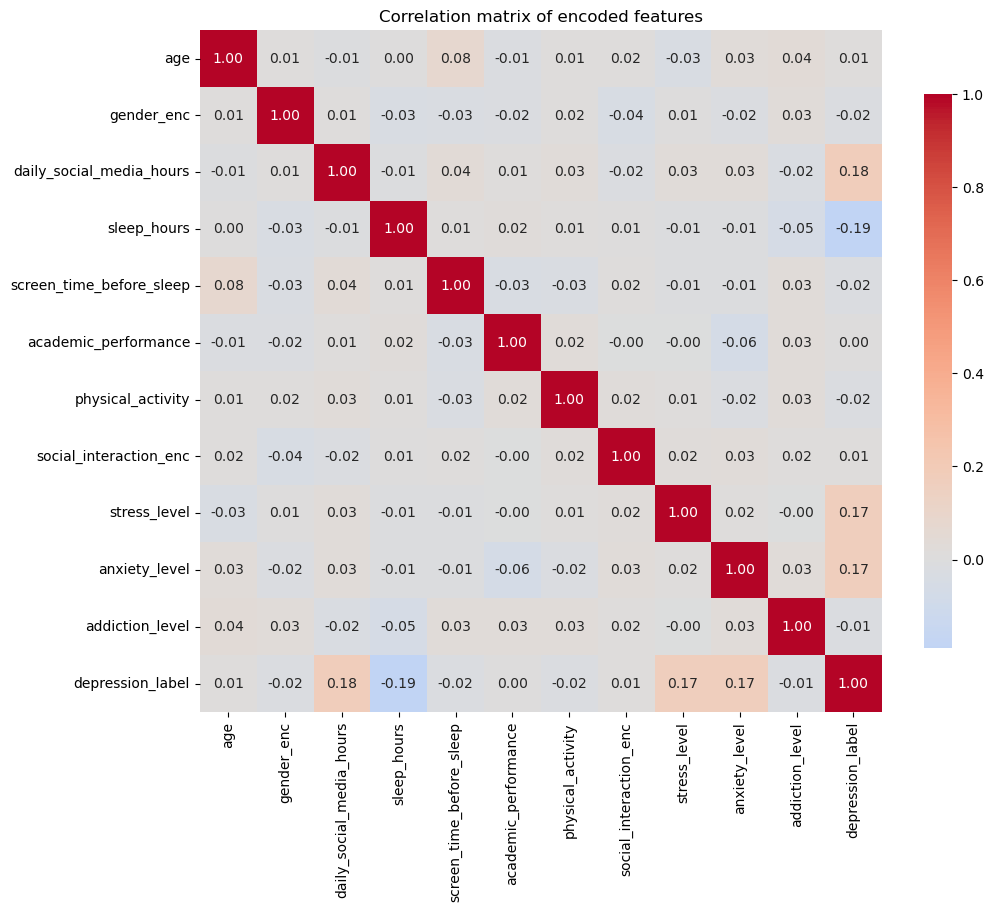

In [12]:
corr = data[feature_cols].corr()
plt.figure(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,square=True, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix of encoded features")

Off-diagonal correlations are near zero. Features are not only uncorrelated with each other but uncorrelated with target.Basically no structure to learn from.

## Preprocessing

We split the data into training (80%) and test (20%) sets with stratification on the target, then standardize the features.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_test_s = scaler.transform(X_test)
X_all_s = scaler.transform(X)
print("Train:", X_train_s.shape, " Test:", X_test_s.shape)
baseline = y.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline:.3f}")

Train: (960, 12)  Test: (240, 12)
Majority-class baseline accuracy: 0.343


## Multinomial Logistic Regression

In [14]:
logreg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
logreg.fit(X_train_s, y_train)
lr_test_acc = accuracy_score(y_test, logreg.predict(X_test_s))
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
lr_cv = cross_val_score(logreg, X_all_s, y, cv=cv, scoring="accuracy")
print(f"Logistic Regression test accuracy: {lr_test_acc:.3f}")
print(f"5-fold CV accuracy: {lr_cv.mean():.3f} (+/- {lr_cv.std():.3f})")
print(f"Baseline: {baseline:.3f}")

Logistic Regression test accuracy: 0.346
5-fold CV accuracy: 0.301 (+/- 0.024)
Baseline: 0.343


## K-Nearest Neighbors w/ Hyperparameter Tuning

In [15]:
param_grid = {"n_neighbors": list(range(1, 32, 2))}
knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=cv, scoring="accuracy")
knn_grid.fit(X_train_s, y_train)
best_k = knn_grid.best_params_["n_neighbors"]
print(f"Best k: {best_k}")
print(f"Best CV accuracy: {knn_grid.best_score_:.3f}")
knn_test_acc = accuracy_score(y_test, knn_grid.predict(X_test_s))
print(f"KNN test accuracy (best k): {knn_test_acc:.3f}")

Best k: 15
Best CV accuracy: 0.360
KNN test accuracy (best k): 0.333


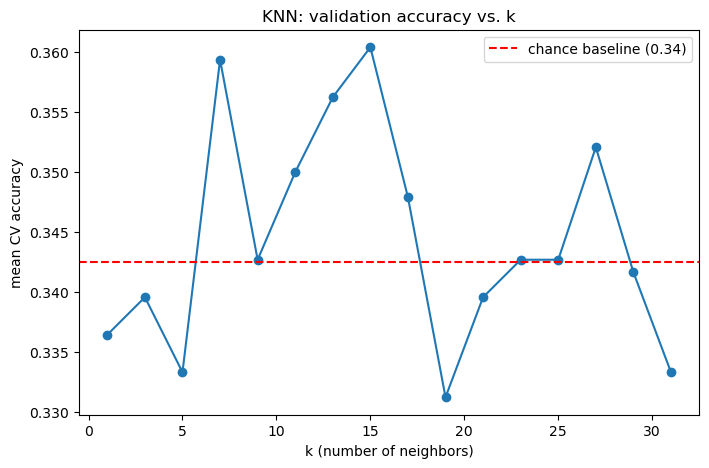

In [16]:
results = knn_grid.cv_results_
plt.plot(param_grid["n_neighbors"], results["mean_test_score"], marker="o")
plt.axhline(baseline, color="red", linestyle="--", label=f"chance baseline ({baseline:.2f})")
plt.xlabel("k (number of neighbors)")
plt.ylabel("mean CV accuracy")
plt.title("KNN: validation accuracy vs. k")
plt.legend()

Accuracy curve hovers around the chance baseline for every value of k. Tuning the hyperparameter doesn't help much because there isnt any real structure.

## Model Evaluation

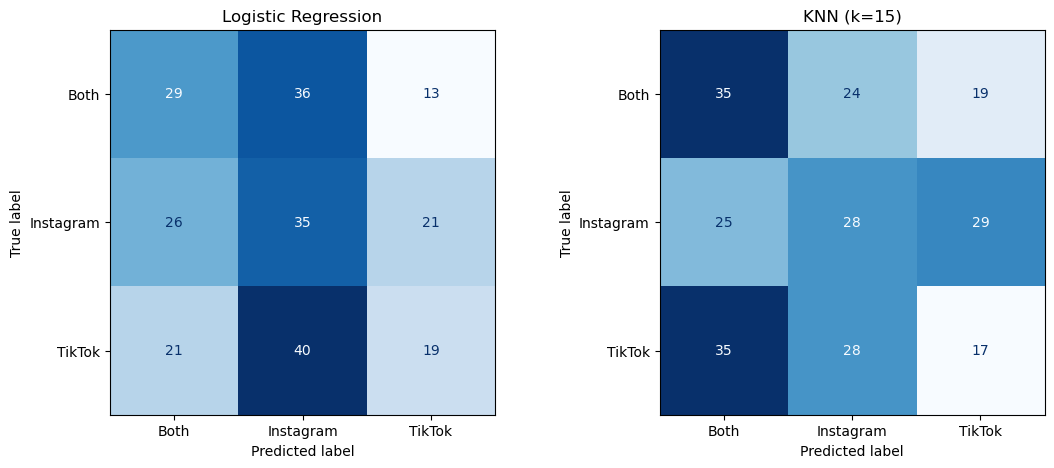

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
labels = sorted(y.unique())
for ax, model, name in [(axes[0], logreg, "Logistic Regression"),(axes[1], knn_grid.best_estimator_, f"KNN (k={best_k})")]:
    cm = confusion_matrix(y_test, model.predict(X_test_s), labels=labels)
    ConfusionMatrixDisplay(cm, display_labels=labels).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

In [18]:
print("Logistic Regression")
print(classification_report(y_test, logreg.predict(X_test_s)))
print("KNN (best k)")
print(classification_report(y_test, knn_grid.best_estimator_.predict(X_test_s)))

Logistic Regression
              precision    recall  f1-score   support

        Both       0.38      0.37      0.38        78
   Instagram       0.32      0.43      0.36        82
      TikTok       0.36      0.24      0.29        80

    accuracy                           0.35       240
   macro avg       0.35      0.35      0.34       240
weighted avg       0.35      0.35      0.34       240

KNN (best k)
              precision    recall  f1-score   support

        Both       0.37      0.45      0.40        78
   Instagram       0.35      0.34      0.35        82
      TikTok       0.26      0.21      0.23        80

    accuracy                           0.33       240
   macro avg       0.33      0.33      0.33       240
weighted avg       0.33      0.33      0.33       240



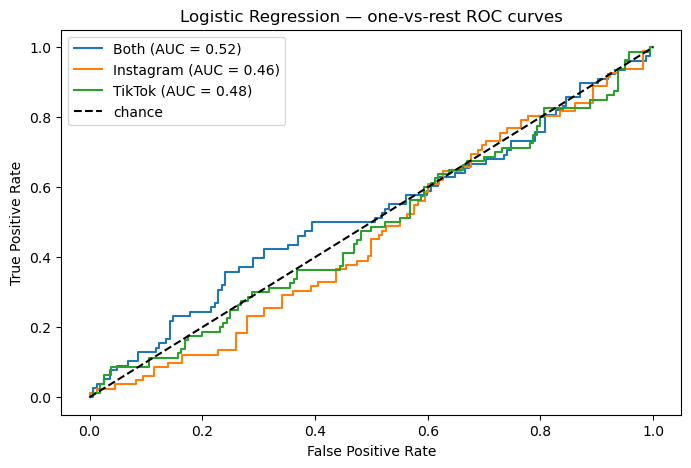

In [19]:
classes = sorted(y.unique())
y_test_bin = label_binarize(y_test, classes=classes)
y_score = logreg.predict_proba(X_test_s)
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc(fpr, tpr):.2f})")
plt.plot([0, 1], [0, 1], "k--", label="chance")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Logistic Regression — one-vs-rest ROC curves")
plt.legend();

All AUC sit near 0.5 value expected from random guessing. A model with power would curve to the top left.

## Data Regularization (LASSO vs. Ridge)

In [20]:
# LASSO (L1)
lasso = LogisticRegression(penalty="l1", solver="saga", max_iter=5000,C=0.05, random_state=RANDOM_STATE)
lasso.fit(X_train_s, y_train)
# Ridge (L2)
ridge = LogisticRegression(penalty="l2", solver="lbfgs", max_iter=5000,C=0.5, random_state=RANDOM_STATE)
ridge.fit(X_train_s, y_train)
print(f"LASSO test accuracy: {accuracy_score(y_test, lasso.predict(X_test_s)):.3f}")
print(f"Ridge test accuracy: {accuracy_score(y_test, ridge.predict(X_test_s)):.3f}")
# How many coefficients zero'd out?
n_zero = int(np.sum(np.all(lasso.coef_ == 0, axis=0)))
print(f"\nFeatures fully zeroed by LASSO: {n_zero} of {len(feature_cols)}")

LASSO test accuracy: 0.354
Ridge test accuracy: 0.346

Features fully zeroed by LASSO: 11 of 12


,feature,LASSO,Ridge
7,social_interaction_enc,0.020261,0.066453
1,gender_enc,0.000000,0.034798
6,physical_activity,0.000000,0.030977
8,stress_level,0.000000,0.028388
11,depression_label,0.000000,0.028167
9,anxiety_level,0.000000,0.027059
0,age,0.000000,0.025311
3,sleep_hours,0.000000,0.024526
10,addiction_level,0.000000,0.023975
5,academic_performance,0.000000,0.023287


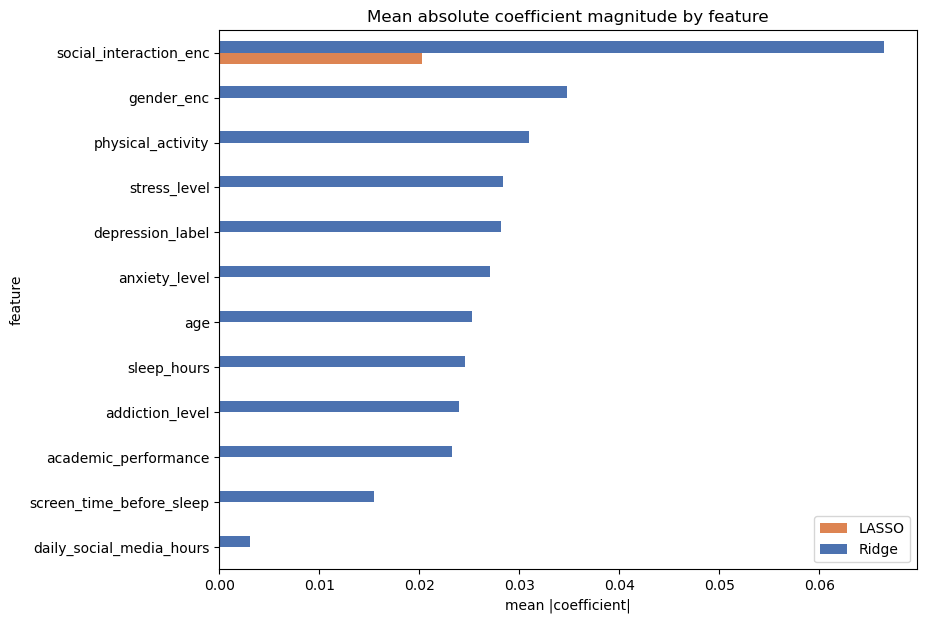

In [21]:
lasso_imp = np.abs(lasso.coef_).mean(axis=0)
ridge_imp = np.abs(ridge.coef_).mean(axis=0)
imp = pd.DataFrame({"feature": feature_cols, "LASSO": lasso_imp, "Ridge": ridge_imp})
imp = imp.sort_values("Ridge", ascending=True)
ax = imp.set_index("feature")[["LASSO", "Ridge"]].plot(kind="barh", figsize=(9, 7), color=["#DD8452", "#4C72B0"])
ax.set_title("Mean absolute coefficient magnitude by feature")
ax.set_xlabel("mean |coefficient|")
imp.sort_values("Ridge", ascending=False)

With a L1 penalty (C=0.05) LASSO zeros out most of the coefficients while accuracy stays near the chance baseline. This is behavior that implies no feature carries predictive signal because the features were never contributing in the first place. The handful of features LASSO kept could be attributed to noise. Likewise the tiny coefficents held by Ridge can be attributed to noise further hinting at lack of structure within the data.

## Conclusion

**Summary**

| Model | Test accuracy | CV accuracy |
|-------|--------------|-------------|
| Majority-class baseline | ~0.34 | — |
| Multinomial Logistic Regression | ~0.35 | ~0.30 |
| KNN (tuned k) | ~0.33 | ~0.32 |
| LASSO logistic | ~0.35 | — |
| Ridge logistic | ~0.35 | — |

**Interpretation**

Every model performs at the ~33% chance level for this three-class problem. We believe the pipeline was carried out correctly therefore the result reflects the data itself:

1. The continuous features are nearly uniform rather than being realistically distributed.
2. One-way ANOVA finds no feature that differs significantly across platform groups.
3. The correlation matrix shows no meaningful relationships among features or with the target.
4. Regularization zeros out coefficients because there is no signal to retain.

All of these together, strongly suggests the dataset was synthetically generated with the features sampled independently of the target. Platform usage cannot be predicted from these mental-health and lifestyle variables because, in this data, the two are statistically unrelated. In this case our finding is that this particular target is not learnable from these features.

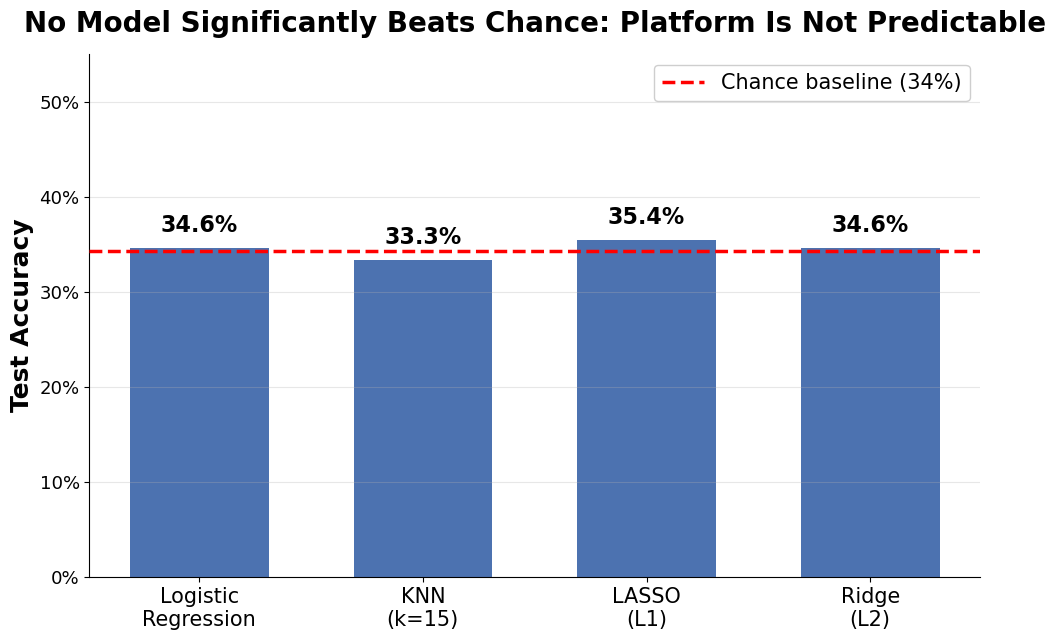

In [31]:
model_names = ["Logistic\nRegression", f"KNN\n(k={best_k})", "LASSO\n(L1)", "Ridge\n(L2)"]
accuracies = [accuracy_score(y_test, logreg.predict(X_test_s)),accuracy_score(y_test, knn_grid.best_estimator_.predict(X_test_s)),accuracy_score(y_test, lasso.predict(X_test_s)),accuracy_score(y_test, ridge.predict(X_test_s)),]
fig, ax = plt.subplots(figsize=(10, 6.5))
bars = ax.bar(model_names, accuracies, color="#4C72B0", width=0.62)
ax.axhline(baseline, color="red", linestyle="--", linewidth=2.5, zorder=4,label=f"Chance baseline ({baseline:.0%})")
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, acc + 0.012, f"{acc:.1%}",ha="center", va="bottom", fontsize=16, fontweight="bold")
ax.set_ylim(0, 0.55)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1.0))
ax.set_ylabel("Test Accuracy", fontsize=18, fontweight="bold")
ax.set_title("No Model Significantly Beats Chance: Platform Is Not Predictable",fontsize=20, fontweight="bold", pad=16)
ax.tick_params(axis="x", labelsize=15)
ax.tick_params(axis="y", labelsize=13)
ax.legend(fontsize=15, loc="upper right", framealpha=0.95)
ax.grid(axis="y", alpha=0.3, zorder=0)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()